# SPY signature adaptive two-step Lasso — project report

**Research question.** Can signatures of recent SPY closes, combined with other quantitative market data, forecast the next trading session's SPY log return?

**Evaluation design.** Daily bars span 2018-01-02 to 2025-03-28. Candidate settings are chosen from forecasts issued in 2023. The untouched comparison period contains forecasts issued 2024-01-02 to 2025-03-27 for target closes 2024-01-03 to 2025-03-28. Each issue date uses a **rolling maximum of 756 matured training examples**, so the exact training dates change at each refit. Section 2 prints the realized calendar boundaries; Section 5 selects the candidate and Section 6 reports held-out results.

**Deliverables.** The model predicts one SPY log return per issue date. `results/daily_refit/` contains per-date forecasts, summary metrics, factor selections and plots.

At the close of session $t$, forecast the **next-session SPY log return** $r_{t+1}=\log(C_{t+1}/C_t)$. The model emits one scalar predicted log return. Prices are used only to construct historical inputs and realized labels; this notebook does not forecast prices or probabilities. Direction accuracy compares the signs of predicted and realized returns.

This notebook adapts Figure 1 and Section 4.1, Equations (9)–(15), of [*Transportation Marketplace Rate Forecast Using Signature Transform*](../Papers/Transportation%20Marketplace%20Rate%20Forecast%20Using%20Signature%20Transform.pdf):

| Paper workflow | SPY implementation |
|---|---|
| Historical response $y$ | Anchored rolling path of SPY log closes; the regression target is next-session SPY log return. |
| Other quantitative factors $X$ | Completed-session QQQ/IWM returns, intraday changes and volatility; FinMultiTime numeric OHLCV/breadth and financial-table fields. News text and chart images are excluded. |
| Correlation analysis | Screen $X$ against historical **same-session** SPY returns, then prune collinear factors, using only the available training period at each refit. |
| $\mathrm{Sig}(y)$ | Exact truncated signature of time plus the historical SPY log-close path. |
| Adaptive weight | A finite, normalized signature-kernel distance on a joint path of SPY history and selected $X$ factors gives softmax sample weights. |
| Two-step Lasso | Weighted Lasso selects a sparse support; weighted **OLS**, with no ridge penalty, refits on exactly that support. |

The paper's word *adaptive* refers to **sample weights from the signature kernel**, not a second set of coefficient penalties. The finite truncated kernel and log-return target are explicit adaptations for this ETF backtest. This is research code; the paper's transport results do not establish SPY forecast skill.

## 1. Settings

The model refits every issue session with matured labels, so it is updated as new daily data arrive. All candidates below have `regime_gamma>0`, ensuring the delivered fit uses adaptive signature weights. Change candidate settings here, choose by validation return MAE, and inspect the held-out test once. `DIRECTION_RETURN_THRESHOLD=0` means predict up when the forecast log return is positive. If you use another threshold, choose it using validation data.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd()
if not (PROJECT / 'src' / 'spy_adaptive_lasso.py').exists():
    PROJECT = Path('Signature_Price_Forecast').resolve()
sys.path.insert(0, str(PROJECT / 'src'))
from spy_adaptive_lasso import (ForecastConfig, TARGET, load_market_data,
                                make_samples, replay, reconstruct_price_comparison,
                                score_predictions,
                                select_factors, save_run)

ROOT = PROJECT.parent
OUTPUT = PROJECT / 'results' / 'daily_refit'

USE_FINMULTITIME = True
DATA_START, DATA_END = '2018-01-01', '2025-03-28'
VALIDATION_START, VALIDATION_END = '2023-01-01', '2023-12-29'
TEST_START, TEST_END = '2024-01-01', '2025-03-27'
DIRECTION_RETURN_THRESHOLD = 0.0

CANDIDATES = {
    'depth2_sparse': ForecastConfig(window=20, signature_depth=2, regime_depth=2,
                                    regime_gamma=0.5, lasso_alpha=0.0005),
    'depth2_less_sparse': ForecastConfig(window=20, signature_depth=2, regime_depth=2,
                                         regime_gamma=0.5, lasso_alpha=0.0001),
    'depth3_less_sparse': ForecastConfig(window=20, signature_depth=3, regime_depth=2,
                                         regime_gamma=0.5, lasso_alpha=0.0001),
    'depth2_stronger_weight': ForecastConfig(window=20, signature_depth=2, regime_depth=2,
                                             regime_gamma=1.0, lasso_alpha=0.0001),
}
print('Target:', TARGET, 'next-session log return')
print('Direction threshold:', DIRECTION_RETURN_THRESHOLD)

Target: SPY next-session log return
Direction threshold: 0.0


## 2. Data provenance and forecast chronology

| Role | Source and fields | Availability at issue close |
|---|---|---|
| Response history and label | `../SP500/attention_data/SPY_daily.csv`: SPY close history; next-session close creates the realized log-return label. | History through issue close; label only after target close. |
| Local quantitative $X$ | `QQQ_daily.csv` and `IWM_daily.csv` in the same folder: daily return, intraday change, 20-session volatility for each ETF. | Completed issue-session bars. |
| FinMultiTime quantitative $X$ | Numeric OHLCV/range and S&P 500 breadth aggregates from the FinMultiTime daily archive. | Completed issue-session data. |
| FinMultiTime filing-table $X$ | Numeric assets, liabilities, equity and cash ratios plus filing coverage. | First usable on the session **after** filing date. |

The default input has 19 candidate quantitative $X$ fields (6 ETF fields, 8 FinMultiTime price/breadth fields and 5 filing-table fields). News text and chart images are outside this numerical experiment. The data loader intersects dates across SPY, QQQ and IWM. The output below records the dates and coverage actually loaded, followed by the issue/target/training chronology used by the backtest.

All factor values are known by the issue-session close. The local QQQ/IWM columns come from the same dated bars as SPY. FinMultiTime numeric prices and breadth use same-session information; SEC financial-table fields are first exposed on the **session after** their filing date. Text and chart image arrays are not used. FinMultiTime's public snapshot in this project ends on 2025-03-28, and the S&P price archive may have survivor bias. First-time source construction needs internet access; cached runs are faster. Set `USE_FINMULTITIME=False` for only local ETF numeric factors.

Common sessions: 1820 2018-01-02 to 2025-03-28
Quantitative X columns: 19


,factor
0,QQQ_return
1,IWM_return
2,QQQ_intraday
3,IWM_intraday
4,QQQ_volatility20
5,IWM_volatility20
6,SPY_high_low_range
7,SPY_log_volume
8,QQQ_high_low_range
9,QQQ_log_volume


,finmultitime_quantitative,filing_sessions,factor_count,text_and_images_used
0,True,1820,19,False


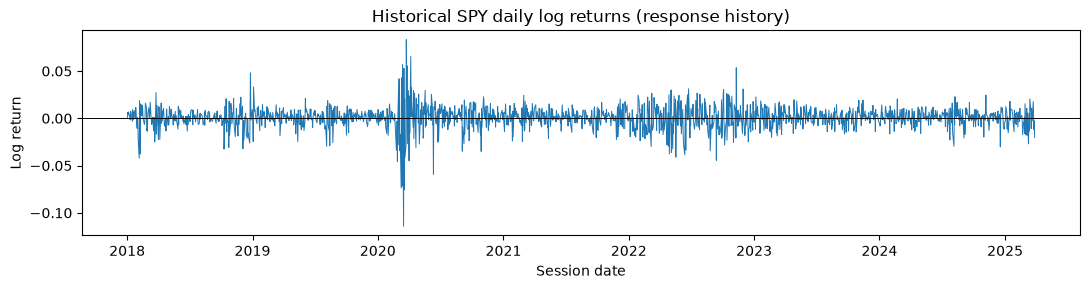

In [2]:
market = load_market_data(ROOT, use_finmultitime=USE_FINMULTITIME,
                          start=DATA_START, end=DATA_END)
print('Common sessions:', len(market['dates']), market['dates'][0].date(),
      'to', market['dates'][-1].date())
print('Quantitative X columns:', len(market['factor_names']))
display(pd.DataFrame({'factor': market['factor_names']}))
display(pd.DataFrame([market['coverage']]))
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(market['dates'], market['spy_return'], linewidth=.7)
ax.set(title='Historical SPY daily log returns (response history)',
       ylabel='Log return', xlabel='Session date')
ax.axhline(0, color='black', linewidth=.7)
fig.tight_layout()
plt.show()

## 3. Train-only factor screen and response signature

For a training cutoff, Pearson correlation between each current $X_{t,j}$ and the **observed current** SPY return $r_t$ ranks factors. The screen retains factors above `correlation_min`, drops near-duplicates above `collinearity_max`, and caps the count at `max_factors`. This screening is repeated at each live-style refit using only then-available history. It is **not** run once on the whole dataset.

For the internal response path, $y_{t-L+1:t}$ is the anchored log-close trajectory with time as an additional channel. Depth $N$ produces $\sum_{k=1}^{N}2^k$ signature coordinates. The forecast design is $[X_t^{\mathrm{selected}},\mathrm{Sig}^N(y_{t-L+1:t})]$.

In [3]:
examples = {}
for name, cfg in CANDIDATES.items():
    examples[name] = make_samples(market, cfg)
summary = pd.DataFrame([{'candidate': name, 'window': cfg.window,
                         'response_signature_depth': cfg.signature_depth,
                         'response_signature_coordinates': examples[name]['y_signature'].shape[1],
                         'regime_depth': cfg.regime_depth, 'kernel_temperature': cfg.regime_gamma}
                        for name, cfg in CANDIDATES.items()])
display(summary)

example_samples = examples['depth3_less_sparse']
training_mask = example_samples['target_dates'] < pd.Timestamp(VALIDATION_START)
training_indices = np.flatnonzero(training_mask)
initial_screen, correlations = select_factors(example_samples['x'][training_indices],
                                               example_samples['y_issue'][training_indices],
                                               CANDIDATES['depth3_less_sparse'])
screen_table = pd.DataFrame({'factor': market['factor_names'],
                             'corr_with_current_SPY_return': correlations,
                             'initially_selected': [i in initial_screen for i in range(len(correlations))]})
display(screen_table.reindex(screen_table.corr_with_current_SPY_return.abs().sort_values(ascending=False).index))

,candidate,window,response_signature_depth,response_signature_coordinates,regime_depth,kernel_temperature
0,depth2_sparse,20,2,6,2,0.5
1,depth2_less_sparse,20,2,6,2,0.5
2,depth3_less_sparse,20,3,14,2,0.5
3,depth2_stronger_weight,20,2,6,2,1.0


,factor,corr_with_current_SPY_return,initially_selected
0,QQQ_return,0.930995,True
10,SP500_mean_return,0.907193,True
1,IWM_return,0.890420,False
12,SP500_fraction_up,0.823371,True
2,QQQ_intraday,0.698459,True
3,IWM_intraday,0.659167,True
7,SPY_log_volume,-0.215727,True
8,QQQ_high_low_range,-0.213545,True
6,SPY_high_low_range,-0.189288,True
9,QQQ_log_volume,-0.187240,False


### Actual rolling training and prediction dates

For every forecast, training includes only examples whose **target date is no later than the issue date**. The last 756 eligible examples are retained. The table shows representative boundaries after the 20-session lookback has been applied. These are issue dates for model fitting and prediction; target dates are the next completed market session.

In [4]:
schedule_samples = examples['depth2_sparse']
issue_dates = pd.to_datetime(schedule_samples['issue_dates'])
target_dates = pd.to_datetime(schedule_samples['target_dates'])
def schedule_row(label, requested_issue):
    issue_index = int(issue_dates.searchsorted(pd.Timestamp(requested_issue)))
    issue = issue_dates[issue_index]
    eligible = int(target_dates.searchsorted(issue, side='right'))
    first = max(0, eligible - CANDIDATES['depth2_sparse'].max_train)
    return {'checkpoint': label, 'forecast_issue': issue.date(),
            'forecast_target': target_dates[issue_index].date(),
            'training_issue_first': issue_dates[first].date(),
            'training_issue_last': issue_dates[eligible-1].date(),
            'latest_training_target': target_dates[eligible-1].date(),
            'training_examples': eligible-first}
timeline = pd.DataFrame([
    schedule_row('First validation forecast', VALIDATION_START),
    schedule_row('First held-out forecast', TEST_START),
    schedule_row('Last held-out forecast', TEST_END),
])
display(timeline)
print('Usable sample issue range:', issue_dates.min().date(), 'to', issue_dates.max().date())
print('Validation issue range:', VALIDATION_START, 'to', VALIDATION_END)
print('Held-out issue range:', TEST_START, 'to', TEST_END)

,checkpoint,forecast_issue,forecast_target,training_issue_first,training_issue_last,latest_training_target,training_examples
0,First validation forecast,2023-01-03,2023-01-04,2020-01-02,2022-12-30,2023-01-03,756
1,First held-out forecast,2024-01-02,2024-01-03,2020-12-29,2023-12-29,2024-01-02,756
2,Last held-out forecast,2025-03-27,2025-03-28,2022-03-22,2025-03-26,2025-03-27,756


Usable sample issue range: 2018-01-30 to 2025-03-27
Validation issue range: 2023-01-01 to 2023-12-29
Held-out issue range: 2024-01-01 to 2025-03-27


## 4. Adaptive sample weights and two-step regression

For each past training window and the current window, build a joint path from normalized time, anchored SPY log closes, and up to `regime_factors` of the screened quantitative factor histories. The joint path stops at its own issue close; it never contains that sample's future target. This is a causal adaptation of the paper's labeled $z=(x,y)$ notation. Let $\phi(z)$ be its normalized depth-`regime_depth` signature. The finite signature kernel is $k(a,b)=\langle\phi(a),\phi(b)\rangle/D$, with distance $d^2=k(a,a)-2k(a,b)+k(b,b)$. Training weights are

$$w_i=\frac{\exp(-\gamma d_i^2)}{\sum_j\exp(-\gamma d_j^2)}.$$

`regime_gamma=0` gives equal weights; larger values emphasize similar recent states. This is a **finite truncated approximation** of the paper's signature kernel. Its effective sample size $1/\sum_i w_i^2$ is saved for diagnosis.

At every issue close, fit:

1. **Weighted Lasso:** $\hat\beta^{(1)}=\arg\min_\beta\;\tfrac12\sum_i w_i(y_i-a-z_i^T\beta)^2+\lambda\|\beta\|_1$.
2. **Weighted OLS:** set $S=\mathrm{supp}(\hat\beta^{(1)})$; minimize $\sum_iw_i(y_i-a-z_{i,S}^T\beta_S)^2$ with coefficients outside $S$ fixed to zero.

Only labels with target date at or before the issue close are allowed in either step. The second step removes the Lasso shrinkage; it does **not** add ridge regularization. Correlation screening and all normalization statistics also use only past training rows.

## 5. Chronological validation

Compare a small prespecified candidate set on 2023. Select the lowest SPY log-return MAE. The 2024–2025 test period is kept out of this choice. The zero-return baseline always forecasts 0; `majority_baseline` is the more frequent actual direction in the evaluation slice and is a hindsight diagnostic.

In [5]:
validation_frames = {}
rows = []
for name, cfg in CANDIDATES.items():
    frame = replay(examples[name], cfg, VALIDATION_START, VALIDATION_END)
    validation_frames[name] = frame
    metric = score_predictions(frame, DIRECTION_RETURN_THRESHOLD).iloc[0]
    rows.append({'candidate': name, 'validation_return_mae': metric.return_mae,
                 'validation_direction_accuracy': metric.direction_accuracy,
                 'validation_return_rmse': metric.return_rmse,
                 'median_lasso_support': frame.lasso_support_count.median(),
                 'median_effective_train_n': frame.effective_train_n.median()})
selection = pd.DataFrame(rows).sort_values('validation_return_mae').reset_index(drop=True)
BEST_NAME = selection.loc[0, 'candidate']
BEST_CONFIG = CANDIDATES[BEST_NAME]
display(selection)
print('Chosen using validation return MAE:', BEST_NAME)
display(score_predictions(validation_frames[BEST_NAME], DIRECTION_RETURN_THRESHOLD))

,candidate,validation_return_mae,validation_direction_accuracy,validation_return_rmse,median_lasso_support,median_effective_train_n
0,depth2_sparse,0.006487,0.504,0.008253,1.0,668.338011
1,depth3_less_sparse,0.006517,0.496,0.008300,10.0,668.338011
2,depth2_less_sparse,0.006528,0.480,0.008299,7.0,668.338011
3,depth2_stronger_weight,0.006536,0.532,0.008301,7.0,570.863187


Chosen using validation return MAE: depth2_sparse


,ticker,n,threshold_log_return,direction_accuracy,majority_baseline,up_rate,predicted_up_rate,return_mae,return_rmse,zero_return_mae
0,SPY,250,0.0,0.504,0.56,0.56,0.896,0.006487,0.008253,0.006484


## 6. Held-out test

Replay the selected model on 2024-01-02 through 2025-03-27. It refits daily with newly matured labels, as an online daily process would. The test is a historical simulation rather than live performance. Inspect both numerical accuracy and the size of errors; direction accuracy alone can be misleading when one direction dominates.

In [6]:
test_frame = replay(examples[BEST_NAME], BEST_CONFIG, TEST_START, TEST_END)
test_metrics = score_predictions(test_frame, DIRECTION_RETURN_THRESHOLD)
display(test_metrics)
row = test_metrics.iloc[0]
print(f"Held-out period: {len(test_frame)} issue sessions, "
      f"{pd.to_datetime(test_frame.issue_date).min().date()} to "
      f"{pd.to_datetime(test_frame.issue_date).max().date()}; "
      f"targets {pd.to_datetime(test_frame.target_date).min().date()} to "
      f"{pd.to_datetime(test_frame.target_date).max().date()}")
print(f"Direction accuracy: {row.direction_accuracy:.1%}; "
      f"majority-direction diagnostic: {row.majority_baseline:.1%}; "
      f"return MAE: {row.return_mae:.6f}; zero-return MAE: {row.zero_return_mae:.6f}")
save_run(OUTPUT, test_frame, BEST_CONFIG, test_metrics, market['coverage'])
selection.to_csv(OUTPUT / 'validation_selection.csv', index=False)

factor_counts = (test_frame.selected_factors.str.split(';').explode()
                 .value_counts().rename_axis('factor').reset_index(name='selected_sessions'))
factor_counts.to_csv(OUTPUT / 'selected_factor_frequency.csv', index=False)
display(factor_counts.head(12))
print('Saved results in:', OUTPUT)

,ticker,n,threshold_log_return,direction_accuracy,majority_baseline,up_rate,predicted_up_rate,return_mae,return_rmse,zero_return_mae
0,SPY,310,0.0,0.587097,0.577419,0.577419,0.964516,0.006277,0.008449,0.006338


Held-out period: 310 issue sessions, 2024-01-02 to 2025-03-27; targets 2024-01-03 to 2025-03-28
Direction accuracy: 58.7%; majority-direction diagnostic: 57.7%; return MAE: 0.006277; zero-return MAE: 0.006338


,factor,selected_sessions
0,QQQ_return,310
1,SP500_mean_return,310
2,SP500_fraction_up,310
3,QQQ_intraday,310
4,IWM_intraday,310
5,SPY_log_volume,310
6,QQQ_high_low_range,310
7,QQQ_log_volume,258
8,SPY_high_low_range,52


Saved results in: C:\Users\Administrator\我的云端硬盘\My_Trading_System\Signature_Price_Forecast\results\daily_refit


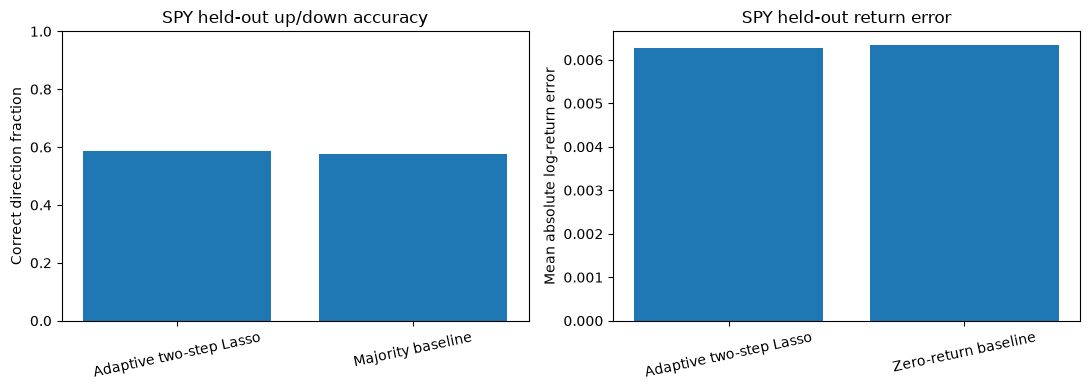

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
row = test_metrics.iloc[0]
axes[0].bar(['Adaptive two-step Lasso', 'Majority baseline'],
            [row.direction_accuracy, row.majority_baseline])
axes[0].set(ylim=(0, 1), ylabel='Correct direction fraction',
            title='SPY held-out up/down accuracy')
axes[1].bar(['Adaptive two-step Lasso', 'Zero-return baseline'],
            [row.return_mae, row.zero_return_mae])
axes[1].set(ylabel='Mean absolute log-return error', title='SPY held-out return error')
for ax in axes:
    ax.tick_params(axis='x', labelrotation=12)
fig.tight_layout()
fig.savefig(OUTPUT / 'test_accuracy_and_return_error.png', dpi=160)
plt.show()

## 7. Fine-tuning and limitations

- Change `window`, `signature_depth`, `regime_depth`, `lasso_alpha`, `regime_gamma`, `correlation_min`, `collinearity_max`, `max_factors`, `regime_factors`, and `max_train` in `CANDIDATES`. Select them on validation, then keep the test untouched.
- Correlation screening uses *contemporaneous* SPY returns to mirror the paper's $X,y$ analysis. That relationship need not predict the next return.
- FinMultiTime images and news are intentionally excluded because this experiment treats $X$ as other **quantitative** data. Tables are numeric and subject to filing-date delays. S&P breadth may carry constituent survivor bias.
- Daily refits are online in the sense of updating after newly observed closes; this notebook is not an always-running service. A live system needs publication cutoffs, data-version logging, and prospective monitoring.
- A positive test result would still need comparison with additional baselines, costs, and later time periods before use. Poor test performance should be reported as such.

The implementation is in `src/spy_adaptive_lasso.py`. `tests/test_spy_adaptive_lasso.py` checks signature identities, the training-only screen, the weighted OLS second step, and label timing. Price reconstruction below is a visualization derived from predicted returns, not an additional model output.

## 8. Test session after a chosen date

Set `SESSION_AFTER_DATE` to a date inside the held-out test range. This section selects forecasts **issued strictly after** that date from the completed daily replay and plots real versus predicted SPY next-session log returns. The horizontal axis is the target close date. Changing only this date does not alter the fitted forecasts.

,ticker,n,threshold_log_return,direction_accuracy,majority_baseline,up_rate,predicted_up_rate,return_mae,return_rmse,zero_return_mae
0,SPY,142,0.0,0.591549,0.56338,0.56338,0.957746,0.006632,0.008939,0.006683


Issue sessions: 2024-09-03 through 2025-03-27


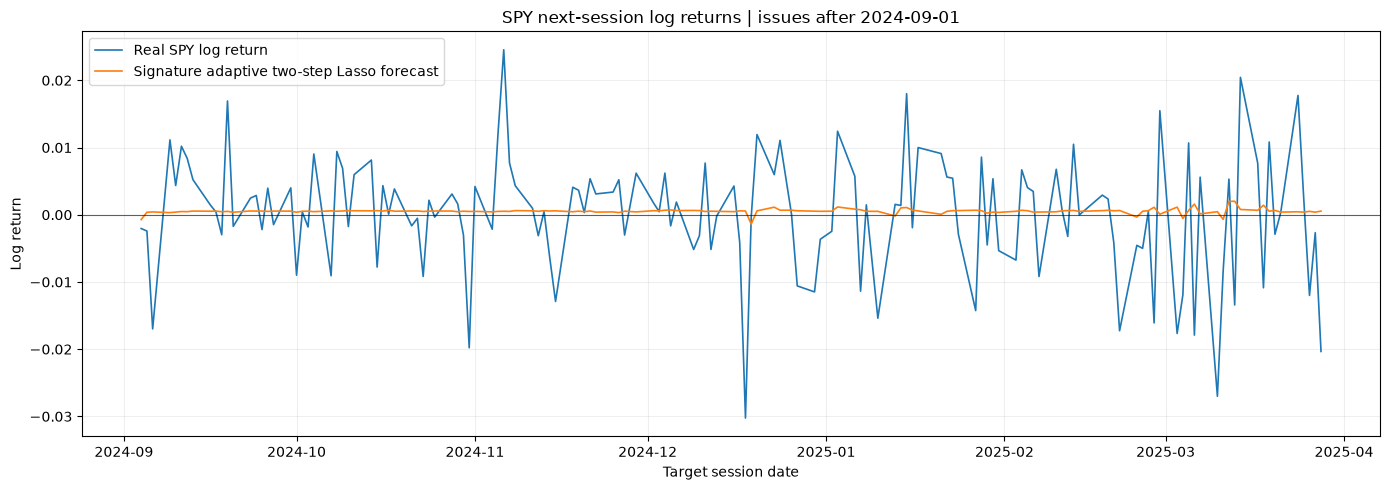

In [8]:
SESSION_AFTER_DATE = '2024-09-01'
after = pd.Timestamp(SESSION_AFTER_DATE)
if not pd.Timestamp(TEST_START) <= after < pd.Timestamp(TEST_END):
    raise ValueError('SESSION_AFTER_DATE must lie inside the held-out test period.')
session_frame = test_frame.loc[pd.to_datetime(test_frame.issue_date) > after].copy()
if session_frame.empty:
    raise ValueError('No held-out forecasts after this date.')
session_frame.to_csv(OUTPUT / 'test_session_returns.csv', index=False)
display(score_predictions(session_frame, DIRECTION_RETURN_THRESHOLD))
print('Issue sessions:', session_frame.issue_date.min(), 'through', session_frame.issue_date.max())

fig, ax = plt.subplots(figsize=(14, 5))
target_dates = pd.to_datetime(session_frame.target_date)
ax.plot(target_dates, session_frame.actual_return, label='Real SPY log return', linewidth=1.2)
ax.plot(target_dates, session_frame.predicted_return,
        label='Signature adaptive two-step Lasso forecast', linewidth=1.2)
ax.axhline(0, color='black', linewidth=.8, alpha=.6)
ax.set(title=f'SPY next-session log returns | issues after {SESSION_AFTER_DATE}',
       xlabel='Target session date', ylabel='Log return')
ax.grid(alpha=.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / 'test_session_returns.png', dpi=160)
plt.show()

## 9. Reconstructed SPY prices after the same date

For each forecast issued at close $t$, use the **actual SPY close from that issue session**, $C_t$, and the predicted log return to calculate $\hat C_{t+1}=C_t\exp(\hat r_{t+1})$. The real comparison value is the next session's actual SPY close. Every predicted price is anchored to its own prior **actual** close; forecast errors are not compounded into later days. This conversion is for evaluation and plotting only: the model output remains a log return.

,issue_date,target_date,previous_actual_close,actual_close,predicted_close
0,2024-09-03,2024-09-04,537.95,536.85,537.564015
1,2024-09-04,2024-09-05,536.85,535.55,537.050506
2,2024-09-05,2024-09-06,535.55,526.53,535.776250
3,2024-09-06,2024-09-09,526.53,532.43,526.698420
4,2024-09-09,2024-09-10,532.43,534.75,532.643151


Price MAE after 2024-09-01: 3.784 USD
Last-close baseline MAE: 3.812 USD


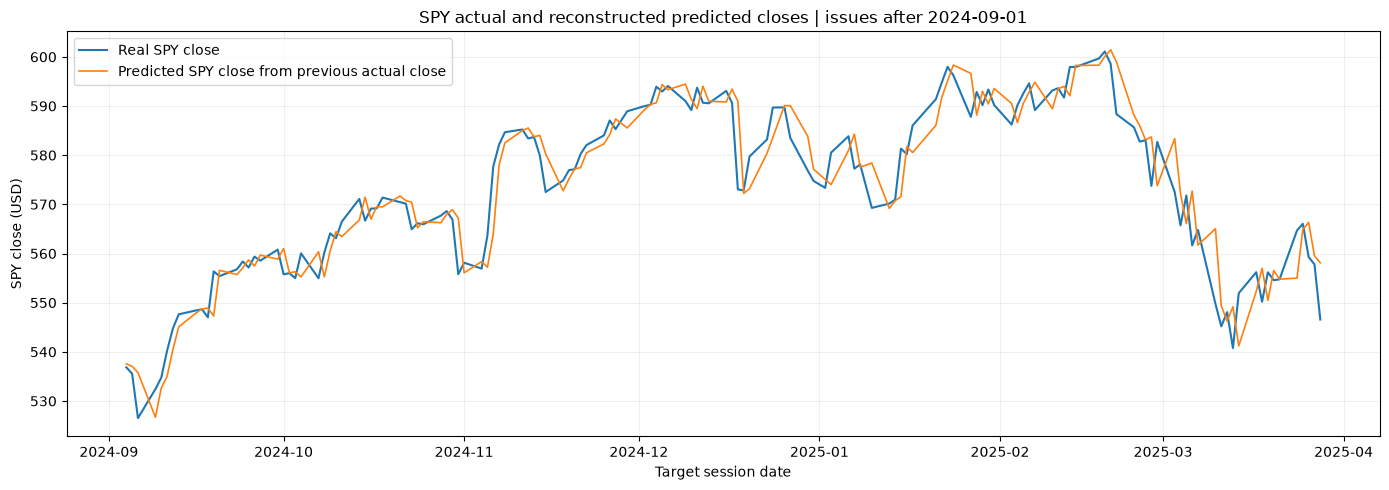

In [9]:
session_prices = reconstruct_price_comparison(session_frame, market)
session_prices.to_csv(OUTPUT / 'test_session_prices.csv', index=False)
display(session_prices[['issue_date', 'target_date', 'previous_actual_close',
                        'actual_close', 'predicted_close']].head())
price_mae = np.mean(np.abs(session_prices.predicted_close - session_prices.actual_close))
last_close_mae = np.mean(np.abs(session_prices.previous_actual_close - session_prices.actual_close))
print(f'Price MAE after {SESSION_AFTER_DATE}: {price_mae:.3f} USD')
print(f'Last-close baseline MAE: {last_close_mae:.3f} USD')

fig, ax = plt.subplots(figsize=(14, 5))
dates_for_price = pd.to_datetime(session_prices.target_date)
ax.plot(dates_for_price, session_prices.actual_close,
        label='Real SPY close', linewidth=1.5)
ax.plot(dates_for_price, session_prices.predicted_close,
        label='Predicted SPY close from previous actual close', linewidth=1.2)
ax.set(title=f'SPY actual and reconstructed predicted closes | issues after {SESSION_AFTER_DATE}',
       xlabel='Target session date', ylabel='SPY close (USD)')
ax.grid(alpha=.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / 'test_session_prices.png', dpi=160)
plt.show()

## 10. Full-test Pearson Corr and normalized MSE

This section computes one Pearson correlation over **all forecasts in the complete held-out test period**. The after-date plotting filter does not affect this value. Normalized MSE is also computed on the full test; no settings are selected from these results.

**Pearson Corr.** $\mathrm{Corr}=\mathrm{corr}(\hat r_t,r_t)$ measures linear association between predicted and realized returns across sessions. A positive value means forecasts track return variations. It is not the percentage of correctly predicted signs; the separate direction-accuracy metric measures that. Constant series have undefined correlation.

**Normalized MSE.** Normalize both forecasts and outcomes with the **same frozen training mean and standard deviation**: $\hat z_t=(\hat r_t-\mu_{train})/\sigma_{train}$ and $z_t=(r_t-\mu_{train})/\sigma_{train}$. Then $\mathrm{NMSE}=N^{-1}\sum_t(\hat z_t-z_t)^2=\mathrm{MSE}/\sigma_{train}^2$. Lower is better. The reference is the selected model's last `max_train` matured labels at the **first test issue close**. It is fitted once using information then available, never estimated from test outcomes. Independently standardizing the prediction and outcome series would remove amplitude errors, so it would not measure the same magnitude fidelity.

Definition references: [SciPy Pearson correlation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) and [scikit-learn MSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html).

In [10]:
import json

def safe_pearson(predicted, realized):
    p, y = np.asarray(predicted, dtype=float), np.asarray(realized, dtype=float)
    if len(p) != len(y) or not np.isfinite(p).all() or not np.isfinite(y).all():
        raise ValueError('Correlation requires aligned, finite prediction/outcome pairs.')
    if len(p) < 2 or np.std(p) <= 1e-14 or np.std(y) <= 1e-14:
        return np.nan
    return float(np.corrcoef(p, y)[0, 1])

reference_samples = examples[BEST_NAME]
first_test_issue = pd.Timestamp(test_frame.issue_date.iloc[0])
eligible = int(reference_samples['target_dates'].searchsorted(first_test_issue, side='right'))
reference_first = max(0, eligible - BEST_CONFIG.max_train)
normalization_labels = reference_samples['targets'][reference_first:eligible]
NORMALIZATION_MEAN = float(np.mean(normalization_labels))
NORMALIZATION_STD = float(np.std(normalization_labels, ddof=1))
if len(normalization_labels) < 2 or not np.isfinite(NORMALIZATION_STD) or NORMALIZATION_STD <= 1e-14:
    raise ValueError('Training reference has insufficient variation for normalization.')
normalization_info = {
    'method': 'shared frozen training z-score', 'reference_issue_close': str(first_test_issue.date()),
    'training_examples': len(normalization_labels),
    'training_issue_first': str(reference_samples['issue_dates'][reference_first].date()),
    'training_issue_last': str(reference_samples['issue_dates'][eligible-1].date()),
    'latest_training_target': str(reference_samples['target_dates'][eligible-1].date()),
    'mean_log_return': NORMALIZATION_MEAN, 'std_log_return_ddof1': NORMALIZATION_STD,
}
display(pd.DataFrame([normalization_info]))
(OUTPUT / 'return_normalization.json').write_text(json.dumps(normalization_info, indent=2), encoding='utf-8')

y = test_frame.actual_return.to_numpy(float)
p = test_frame.predicted_return.to_numpy(float)
FULL_TEST_CORR = safe_pearson(p, y)
z_y = (y-NORMALIZATION_MEAN)/NORMALIZATION_STD
z_p = (p-NORMALIZATION_MEAN)/NORMALIZATION_STD
normalized_mse = float(np.mean((z_p-z_y)**2))
zero_normalized_mse = float(np.mean((y/NORMALIZATION_STD)**2))
additional_metrics = pd.DataFrame([{
    'evaluation': 'Full held-out test', 'n': len(test_frame),
    'issue_first': str(test_frame.issue_date.min()), 'issue_last': str(test_frame.issue_date.max()),
    'Pearson_Corr': FULL_TEST_CORR,
    'MSE_log_returns': float(np.mean((p-y)**2)),
    'MSE_shared_training_normalized': normalized_mse,
    'zero_return_normalized_MSE': zero_normalized_mse,
    'MSE_skill_vs_zero': 1-normalized_mse/zero_normalized_mse,
}])
display(additional_metrics)
additional_metrics.to_csv(OUTPUT / 'additional_return_metrics.csv', index=False)
print('Saved full-test metrics in:', OUTPUT / 'additional_return_metrics.csv')

,method,reference_issue_close,training_examples,training_issue_first,training_issue_last,latest_training_target,mean_log_return,std_log_return_ddof1
0,shared frozen training z-score,2024-01-02,756,2020-12-29,2023-12-29,2024-01-02,0.000377,0.011073


,evaluation,n,issue_first,issue_last,Pearson_Corr,MSE_log_returns,MSE_shared_training_normalized,zero_return_normalized_MSE,MSE_skill_vs_zero
0,Full held-out test,310,2024-01-02,2025-03-27,0.015146,0.000071,0.582202,0.584622,0.00414


Saved full-test metrics in: C:\Users\Administrator\我的云端硬盘\My_Trading_System\Signature_Price_Forecast\results\daily_refit\additional_return_metrics.csv


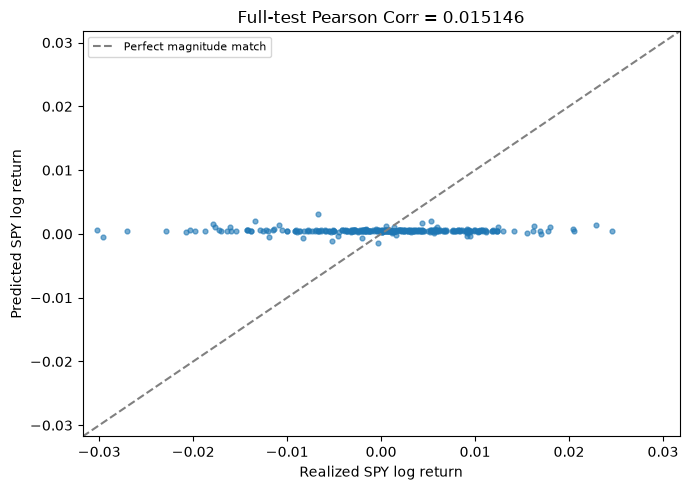

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(test_frame.actual_return, test_frame.predicted_return, s=12, alpha=.6)
bound = max(np.abs(test_frame.actual_return).max(), np.abs(test_frame.predicted_return).max())*1.05
ax.plot([-bound, bound], [-bound, bound], '--', color='gray', label='Perfect magnitude match')
ax.set(xlim=(-bound, bound), ylim=(-bound, bound),
            xlabel='Realized SPY log return', ylabel='Predicted SPY log return',
            title=f'Full-test Pearson Corr = {FULL_TEST_CORR:.6f}')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / 'additional_return_metrics.png', dpi=160)
plt.show()